In [9]:
import json
import os
from collections import Counter
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [10]:
DATA_DIR = "../data"  
REVIEW_PATH = (
    os.path.join(DATA_DIR, "Video_Games.jsonl")
    if os.path.exists(os.path.join(DATA_DIR, "Video_Games.jsonl"))
    else "data/Video_Games.jsonl"
)
META_PATH = (
    os.path.join(DATA_DIR, "meta_Video_Games.jsonl")
    if os.path.exists(os.path.join(DATA_DIR, "meta_Video_Games.jsonl"))
    else "data/meta_Video_Games.jsonl"
)
print(f"Review file: {REVIEW_PATH} ({os.path.getsize(REVIEW_PATH) / 1024**3:.2f} GB)")
print(f"Meta file:   {META_PATH} ({os.path.getsize(META_PATH) / 1024**2:.2f} MB)")

Review file: ../data\Video_Games.jsonl (2.50 GB)
Meta file:   ../data\meta_Video_Games.jsonl (417.11 MB)


In [11]:
def print_sample(file_path, num_samples=1):
    print(f"\n{'='*30} Sample từ {file_path} {'='*30}")
    with open(file_path, "r", encoding="utf-8") as f:
        for i in range(num_samples):
            line = f.readline()
            if line:
                data = json.loads(line)
                print(json.dumps(data, indent=2, ensure_ascii=False))
print_sample(REVIEW_PATH, num_samples=1)
print_sample(META_PATH, num_samples=1)


============================== Sample từ ../data\Video_Games.jsonl ==============================
{
  "rating": 4.0,
  "title": "It’s pretty sexual. Not my fav",
  "text": "I’m playing on ps5 and it’s interesting.  It’s unique, massive, and has a neat story.  People are freaking out angry about this game.  I don’t think it’s a top 10 game but it’s definitely a good game on ps5 (played at launch).",
  "images": [],
  "asin": "B07DJWBYKP",
  "parent_asin": "B07DK1H3H5",
  "user_id": "AGCI7FAH4GL5FI65HYLKWTMFZ2CQ",
  "timestamp": 1608186804795,
  "helpful_vote": 0,
  "verified_purchase": true
}

============================== Sample từ ../data\meta_Video_Games.jsonl ==============================
{
  "main_category": "Video Games",
  "title": "Dash 8-300 Professional Add-On",
  "average_rating": 5.0,
  "rating_number": 1,
  "features": [
    "Features Dash 8-300 and 8-Q300 ('Q' rollout livery)",
    "Airlines - US Airways, South African Express, Bahamasair, Augsburg Airways, Lufthansa Ci

--- THÔNG TIN METADATA ---
Số lượng sản phẩm (Items): 137,269
Số parent_asin duy nhất: 137,269

Thông tin các cột và kiểu dữ liệu:
<class 'pandas.DataFrame'>
RangeIndex: 137269 entries, 0 to 137268
Data columns (total 16 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   main_category    126234 non-null  str    
 1   title            137269 non-null  str    
 2   average_rating   137269 non-null  float64
 3   rating_number    137269 non-null  int64  
 4   features         137269 non-null  object 
 5   description      137269 non-null  object 
 6   price            62008 non-null   object 
 7   images           137269 non-null  object 
 8   videos           137269 non-null  object 
 9   store            132908 non-null  str    
 10  categories       137269 non-null  object 
 11  details          137269 non-null  object 
 12  parent_asin      137269 non-null  str    
 13  bought_together  0 non-null       object 
 14  subtitle    

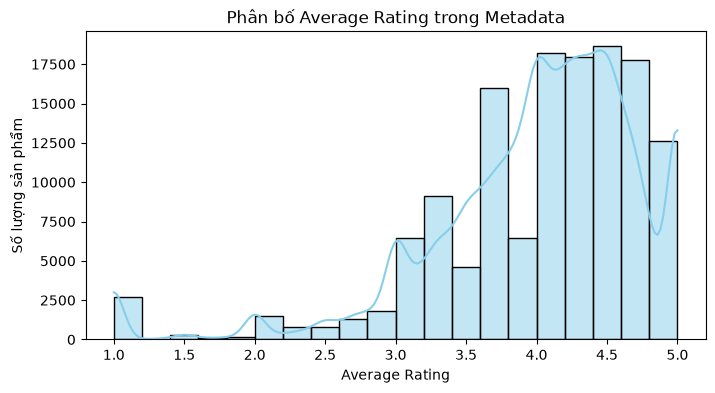

In [13]:
# Đọc meta_Video_Games.jsonl
meta_records = []
with open(META_PATH, "r", encoding="utf-8") as f:
    for line in f:
        meta_records.append(json.loads(line))
df_meta = pd.DataFrame(meta_records)
print(f"--- THÔNG TIN METADATA ---")
print(f"Số lượng sản phẩm (Items): {len(df_meta):,}")
print(f"Số parent_asin duy nhất: {df_meta['parent_asin'].nunique():,}")
print(f"\nThông tin các cột và kiểu dữ liệu:")
print(df_meta.info())
print(f"\nTỷ lệ giá trị null / thiếu:")
print((df_meta.isnull().mean() * 100).round(2).to_string())
# Top 10 Store / Nhà phát hành phổ biến
if "store" in df_meta.columns:
    print("\nTop 10 Stores / Brands:")
    print(df_meta["store"].value_counts().head(10))
# Phân bố rating trung bình
plt.figure(figsize=(8, 4))
sns.histplot(
    df_meta["average_rating"].dropna(),
    bins=20,
    kde=True,
    color="skyblue",
    edgecolor="black",
)
plt.title("Phân bố Average Rating trong Metadata")
plt.xlabel("Average Rating")
plt.ylabel("Số lượng sản phẩm")
plt.show()

In [14]:
rating_counter = Counter()
verified_counter = Counter()
unique_users = set()
unique_items = set()
timestamps = []
total_reviews = 0
min_timestamp = float("inf")
max_timestamp = 0

print("Đang quét qua toàn bộ Video_Games.jsonl...")

with open(REVIEW_PATH, "r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        record = json.loads(line)
        total_reviews += 1

        rating_counter[record.get("rating")] += 1
        verified_counter[record.get("verified_purchase")] += 1

        user_id = record.get("user_id")
        parent_asin = record.get("parent_asin")

        if user_id:
            unique_users.add(user_id)
        if parent_asin:
            unique_items.add(parent_asin)

        ts = record.get("timestamp")
        if ts:
            if ts < min_timestamp:
                min_timestamp = ts
            if ts > max_timestamp:
                max_timestamp = ts

        if total_reviews % 1_000_000 == 0:
            print(f"Đã xử lý {total_reviews:,} dòng...")

n_users = len(unique_users)
n_items = len(unique_items)
sparsity = (1 - (total_reviews / (n_users * n_items))) * 100

print("\n" + "=" * 50)
print("--- THỐNG KÊ TẬP TƯƠNG TÁC (REVIEWS) ---")
print(f"Tổng số tương tác (Reviews): {total_reviews:,}")
print(f"Số người dùng (Unique Users): {n_users:,}")
print(f"Số sản phẩm được tương tác (Unique Parent ASINs): {n_items:,}")
print(f"Trung bình review / user: {total_reviews / n_users:.2f}")
print(f"Trung bình review / item: {total_reviews / n_items:.2f}")
print(f"Độ thưa dữ liệu (Matrix Sparsity): {sparsity:.4f}%")

if min_timestamp != float("inf") and max_timestamp != 0:
    min_date = datetime.fromtimestamp(min_timestamp / 1000).strftime(
        "%Y-%m-%d"
    )
    max_date = datetime.fromtimestamp(max_timestamp / 1000).strftime(
        "%Y-%m-%d"
    )
    print(f"Khoảng thời gian: Từ {min_date} đến {max_date}")

print(
    f"Tỷ lệ Verified Purchase: {verified_counter[True] / total_reviews * 100:.2f}%"
)


Đang quét qua toàn bộ Video_Games.jsonl...
Đã xử lý 1,000,000 dòng...
Đã xử lý 2,000,000 dòng...
Đã xử lý 3,000,000 dòng...
Đã xử lý 4,000,000 dòng...

--- THỐNG KÊ TẬP TƯƠNG TÁC (REVIEWS) ---
Tổng số tương tác (Reviews): 4,624,615
Số người dùng (Unique Users): 2,766,656
Số sản phẩm được tương tác (Unique Parent ASINs): 137,249
Trung bình review / user: 1.67
Trung bình review / item: 33.70
Độ thưa dữ liệu (Matrix Sparsity): 99.9988%
Khoảng thời gian: Từ 1998-11-18 đến 2023-09-12
Tỷ lệ Verified Purchase: 86.12%


In [15]:
meta_parent_asins = set(df_meta["parent_asin"].dropna())
overlap_items = unique_items.intersection(meta_parent_asins)
print(f"\n--- ĐỘ PHỦ GIỮA METADATA VÀ REVIEWS ---")
print(f"Số sản phẩm trong Metadata: {len(meta_parent_asins):,}")
print(f"Số sản phẩm trong Reviews:  {len(unique_items):,}")
print(f"Số sản phẩm giao thoa (Overlap): {len(overlap_items):,}")
print(
    f"Tỷ lệ sản phẩm được review có metadata: {len(overlap_items) / len(unique_items) * 100:.2f}%"
)


--- ĐỘ PHỦ GIỮA METADATA VÀ REVIEWS ---
Số sản phẩm trong Metadata: 137,269
Số sản phẩm trong Reviews:  137,249
Số sản phẩm giao thoa (Overlap): 137,249
Tỷ lệ sản phẩm được review có metadata: 100.00%


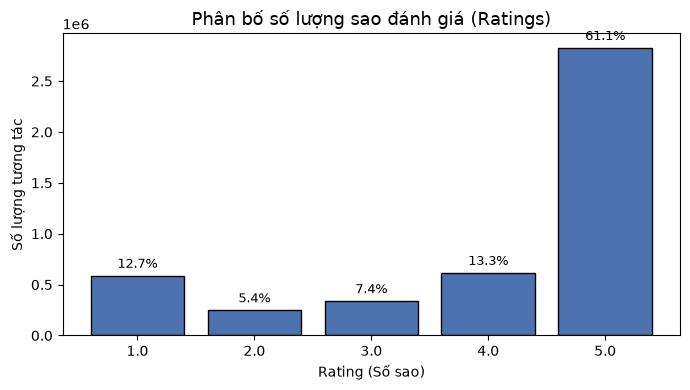

In [16]:
ratings_df = (
    pd.DataFrame.from_dict(
        rating_counter, orient="index", columns=["count"]
    ).sort_index()
)
ratings_df["percent"] = (ratings_df["count"] / total_reviews) * 100

plt.figure(figsize=(7, 4))
bars = plt.bar(
    ratings_df.index.astype(str),
    ratings_df["count"],
    color="#4c72b0",
    edgecolor="black",
)
plt.title("Phân bố số lượng sao đánh giá (Ratings)", fontsize=13)
plt.xlabel("Rating (Số sao)")
plt.ylabel("Số lượng tương tác")

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        yval + (total_reviews * 0.01),
        f"{yval/total_reviews*100:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
plt.show()


### 6. Phân tích phân bố tương tác của User (User Activity Distribution)
Trong Hệ thống Gợi ý (Recommendation System), hiện tượng **Đuôi dài (Long-tail)** là rất phổ biến: phần lớn người dùng chỉ đánh giá 1 hoặc 2 sản phẩm (Cold-start users), trong khi một số ít người dùng hoạt động rất nhiều (Heavy users).

Việc phân tích này giúp ta xác định ngưỡng **K-Core Filtering** (ví dụ: $k=5$) cho Phase 2 để loại bỏ người dùng/sản phẩm có quá ít dữ liệu, giúp ma trận tương tác có đủ tín hiệu học.

In [17]:
# Thu thập số lượng tương tác của từng user và từng item
user_review_counts = Counter()
item_review_counts = Counter()
review_lengths = []
years_counter = Counter()

print("Đang phân tích chi tiết user activity, item popularity, text length...")
with open(REVIEW_PATH, "r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        rec = json.loads(line)
        u = rec.get("user_id")
        p = rec.get("parent_asin")
        txt = rec.get("text", "") or ""
        ts = rec.get("timestamp")
        
        if u:
            user_review_counts[u] += 1
        if p:
            item_review_counts[p] += 1
        
        # Lấy mẫu độ dài text (mỗi 100 dòng lấy 1 mẫu để tiết kiệm RAM)
        if i % 100 == 0:
            review_lengths.append(len(txt.split()))
        
        if ts:
            yr = datetime.fromtimestamp(ts / 1000).year
            years_counter[yr] += 1

print("Hoàn thành quét dữ liệu!")


Đang phân tích chi tiết user activity, item popularity, text length...
Hoàn thành quét dữ liệu!


In [18]:
# Thống kê phân bố User Review Counts (Long-tail analysis)
user_counts_series = pd.Series(list(user_review_counts.values()))

print("--- THỐNG KÊ HOẠT ĐỘNG NGƯỜI DÙNG (USER REVIEWS) ---")
print(f"Tổng số users: {len(user_counts_series):,}")
print(f"Users có đúng 1 review:   {(user_counts_series == 1).sum():,} ({(user_counts_series == 1).mean()*100:.2f}%)")
print(f"Users có >= 3 reviews:    {(user_counts_series >= 3).sum():,} ({(user_counts_series >= 3).mean()*100:.2f}%)")
print(f"Users có >= 5 reviews:    {(user_counts_series >= 5).sum():,} ({(user_counts_series >= 5).mean()*100:.2f}%)")
print(f"Users có >= 10 reviews:   {(user_counts_series >= 10).sum():,} ({(user_counts_series >= 10).mean()*100:.2f}%)")
print(f"User review nhiều nhất:    {user_counts_series.max():,} reviews")

# Thống kê phân bố Item Review Counts
item_counts_series = pd.Series(list(item_review_counts.values()))
print("\n--- THỐNG KÊ ĐỘ PHỔ BIẾN SẢN PHẨM (ITEM POPULARITY) ---")
print(f"Tổng số items: {len(item_counts_series):,}")
print(f"Items có đúng 1 review:   {(item_counts_series == 1).sum():,} ({(item_counts_series == 1).mean()*100:.2f}%)")
print(f"Items có >= 5 reviews:    {(item_counts_series >= 5).sum():,} ({(item_counts_series >= 5).mean()*100:.2f}%)")
print(f"Items có >= 20 reviews:   {(item_counts_series >= 20).sum():,} ({(item_counts_series >= 20).mean()*100:.2f}%)")
print(f"Item có nhiều review nhất: {item_counts_series.max():,} reviews")


--- THỐNG KÊ HOẠT ĐỘNG NGƯỜI DÙNG (USER REVIEWS) ---
Tổng số users: 2,766,656
Users có đúng 1 review:   1,997,753 (72.21%)
Users có >= 3 reviews:    339,168 (12.26%)
Users có >= 5 reviews:    117,742 (4.26%)
Users có >= 10 reviews:   27,017 (0.98%)
User review nhiều nhất:    664 reviews

--- THỐNG KÊ ĐỘ PHỔ BIẾN SẢN PHẨM (ITEM POPULARITY) ---
Tổng số items: 137,249
Items có đúng 1 review:   37,839 (27.57%)
Items có >= 5 reviews:    63,180 (46.03%)
Items có >= 20 reviews:   27,336 (19.92%)
Item có nhiều review nhất: 18,105 reviews


### 7. Phân tích Dòng thời gian (Timeline & Seasonality) và Độ dài Text Review
1. **Timeline**: Xem lượng đánh giá thay đổi thế nào qua các năm (từ 2000 - 2023) để thiết kế chiến lược **Temporal Train/Test Split**.
2. **Text Length**: Đánh giá độ dài từ (*word count*) của đánh giá để chuẩn bị cho Phase 3 (NLP Sentiment & Embedding).

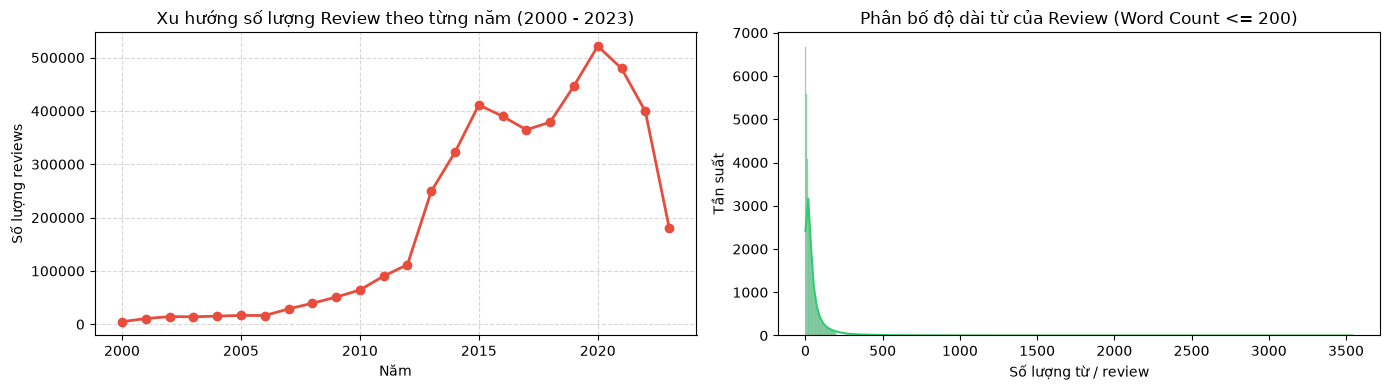

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Biểu đồ 1: Số lượng reviews theo năm
years_df = pd.DataFrame.from_dict(years_counter, orient="index", columns=["count"]).sort_index()
years_df = years_df[years_df.index >= 2000] # Lọc từ năm 2000
axes[0].plot(years_df.index, years_df["count"], marker="o", color="#e74c3c", lw=2)
axes[0].set_title("Xu hướng số lượng Review theo từng năm (2000 - 2023)", fontsize=12)
axes[0].set_xlabel("Năm")
axes[0].set_ylabel("Số lượng reviews")
axes[0].grid(True, linestyle="--", alpha=0.5)

# Biểu đồ 2: Phân bố độ dài từ (Word count) của review
sns.histplot(review_lengths, bins=40, binrange=(0, 200), ax=axes[1], color="#2ecc71", kde=True)
axes[1].set_title("Phân bố độ dài từ của Review (Word Count <= 200)", fontsize=12)
axes[1].set_xlabel("Số lượng từ / review")
axes[1].set_ylabel("Tần suất")

plt.tight_layout()
plt.show()


### 8. Phân tích Thể loại Game (Categories) & Nền tảng (Platforms) trong Metadata
Trích xuất các thể loại và nền tảng chính (PC, PlayStation, Xbox, Nintendo, v.v.) từ trường `categories` để phục vụ cho **Content-Based Recommender**.

C:\Users\Minh Doan\AppData\Local\Temp\ipykernel_3140\2344720610.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_subcats.values, y=top_subcats.index, palette="viridis")


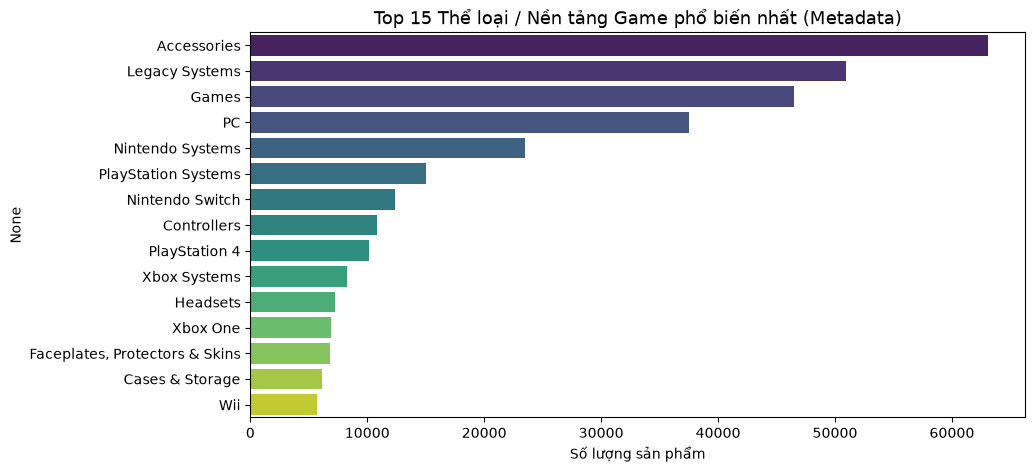

In [20]:
# Trích xuất tất cả category con từ metadata
all_subcats = []
for cat_list in df_meta["categories"].dropna():
    if isinstance(cat_list, list):
        for c in cat_list:
            if c != "Video Games":  # Bỏ category gốc
                all_subcats.append(c)

top_subcats = pd.Series(all_subcats).value_counts().head(15)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_subcats.values, y=top_subcats.index, palette="viridis")
plt.title("Top 15 Thể loại / Nền tảng Game phổ biến nhất (Metadata)", fontsize=13)
plt.xlabel("Số lượng sản phẩm")
plt.show()


### 9. Tổng kết Phát hiện Dữ liệu (Key Insights for Phase 2)

Từ kết quả EDA trên, chúng ta rút ra các quyết định kỹ thuật quan trọng cho hệ thống:
1. **Độ thưa dữ liệu (Sparsity ~99.9%):** Phần lớn user chỉ có 1 review. Để huấn luyện mô hình Collaborative Filtering (Matrix Factorization, Neural CF) hiệu quả, ta cần áp dụng **K-Core Filtering (ví dụ $k=5$)** ở Phase 2.
2. **Độ phủ Metadata là 100%:** Toàn bộ $137,249$ sản phẩm được review đều có metadata chi tiết (title, categories, store, features). Đây là lợi thế lớn để xây dựng **Content-Based Filtering** và giải quyết bài toán **Cold-Start Items**.
3. **Phân bố Rating bị lệch về 5 sao (>65%):** Ta có thể chuyển đổi sang bài toán **Implicit Feedback** (tương tác mua/review = 1, chưa tương tác = 0) hoặc chuẩn hóa rating cho các mô hình phân loại Ranking.
4. **Review Text giàu thông tin:** Hầu hết review có độ dài 20 - 80 từ, rất phù hợp để trích xuất cảm xúc (Sentiment) và tạo Text Embeddings với mô hình NLP nhỏ gọn như `all-MiniLM-L6-v2`.